In [19]:
# Import necessary libraries
import numpy as np  # Numerical computations
import pandas as pd  # Data manipulation
import matplotlib.pyplot as plt  # Plotting
import seaborn as sns  # Statistical visualizations
from scipy import stats  # Statistical functions
from scipy import optimize  # Optimization routines
import warnings  # Handle warnings
warnings.filterwarnings('ignore')

# Set random seed for reproducibility
np.random.seed(42)
plt.style.use('seaborn-v0_8')  # Use modern plotting style

print("=== Maximum Likelihood Estimation Lab ===")
print("This notebook covers MLE theory and applications")

=== Maximum Likelihood Estimation Lab ===
This notebook covers MLE theory and applications


## 1. Introduction to Maximum Likelihood Estimation

### 1.1 The Likelihood Principle

Given observed data $x_1, x_2, \ldots, x_n$ and a probabilistic model $f(x|\theta)$, the **likelihood function** is:

$$L(\theta) = \prod_{i=1}^n f(x_i | \theta)$$

The **Maximum Likelihood Estimator (MLE)** is the parameter value that maximizes this likelihood:

$$\hat{\theta}_{\text{MLE}} = \arg\max_{\theta} L(\theta)$$

**Intuition**: Choose the parameter value that makes our observed data most probable.

### 1.2 Connection to Previous Lessons

- **Lesson 1**: We learned about probability distributions and the Law of Large Numbers (LLN)
- **Lesson 2**: We now apply these concepts to estimate distribution parameters from data
- **Key Insight**: MLE leverages the LLN - as n grows, the MLE converges to the true parameter

## 2. Bernoulli Distribution: A Simple Case Study (Lessons 0–2)

### 2.1 Motivating Example - A/B Testing

Consider an A/B test where we show two variants of a webpage:
- Variant A: 1,000 impressions, 120 clicks
- Variant B: 1,000 impressions, 150 clicks

Each click is a Bernoulli trial with success probability p (click-through rate).

**Question**: Which variant has higher click-through rate?

In [20]:
# Simulate A/B test data
np.random.seed(42)
n_A, n_B = 1000, 1000
clicks_A = np.random.binomial(n_A, 0.12)  # Variant A: 12% CTR
clicks_B = np.random.binomial(n_B, 0.15)  # Variant B: 15% CTR

print(f"Variant A: {clicks_A} clicks out of {n_A} impressions ({clicks_A/n_A*100:.1f}% CTR)")
print(f"Variant B: {clicks_B} clicks out of {n_B} impressions ({clicks_B/n_B*100:.1f}% CTR)")

# Empirical CTR estimates
ctr_A_hat = clicks_A / n_A
ctr_B_hat = clicks_B / n_B

print(f"\nEmpirical CTR estimates:")
print(f"Variant A: {ctr_A_hat:.4f}")
print(f"Variant B: {ctr_B_hat:.4f}")
print(f"Difference: {ctr_B_hat - ctr_A_hat:.4f}")

Variant A: 115 clicks out of 1000 impressions (11.5% CTR)
Variant B: 152 clicks out of 1000 impressions (15.2% CTR)

Empirical CTR estimates:
Variant A: 0.1150
Variant B: 0.1520
Difference: 0.0370


### Question 1 — Derive and implement the Bernoulli MLE

For i.i.d. Bernoulli observations $X_1, \ldots, X_n$:

**Likelihood function**:
$$L(p) = \prod_{i=1}^n p^{x_i} (1-p)^{1-x_i} = p^{\sum x_i} (1-p)^{n - \sum x_i}$$

**Log-likelihood**:
$$\ell(p) = \sum x_i \log p + (n - \sum x_i) \log (1-p)$$

**Derivative**:
$$\frac{d\ell}{dp} = \frac{\sum x_i}{p} - \frac{n - \sum x_i}{1-p}$$

**Set derivative to zero**:
$$\frac{k}{p} = \frac{n-k}{1-p} \implies k(1-p) = p(n-k) \implies k = p n \implies p = \frac{k}{n}$$

**Result**: The MLE is the sample proportion $\hat{p} = \bar{x}_n$

In [21]:
def bernoulli_mle(data):
    """Compute MLE for Bernoulli parameter"""
    return np.mean(data)

def bernoulli_mom(data):
    """Compute Method of Moments estimator for Bernoulli parameter"""
    return np.mean(data)  # Coincides with MLE for Bernoulli

# Test with A/B data
data_A = np.random.binomial(1, 0.12, n_A)
data_B = np.random.binomial(1, 0.15, n_B)

print("=== Bernoulli Parameter Estimation ===")
print(f"Variant A - MLE: {bernoulli_mle(data_A):.4f}, MoM: {bernoulli_mom(data_A):.4f}")
print(f"Variant B - MLE: {bernoulli_mle(data_B):.4f}, MoM: {bernoulli_mom(data_B):.4f}")

=== Bernoulli Parameter Estimation ===
Variant A - MLE: 0.1230, MoM: 0.1230
Variant B - MLE: 0.1520, MoM: 0.1520


### Question 2 — Visualise the Bernoulli log-likelihood

Let's visualize how the likelihood function behaves for different sample sizes and see how the maximum becomes sharper as n increases.

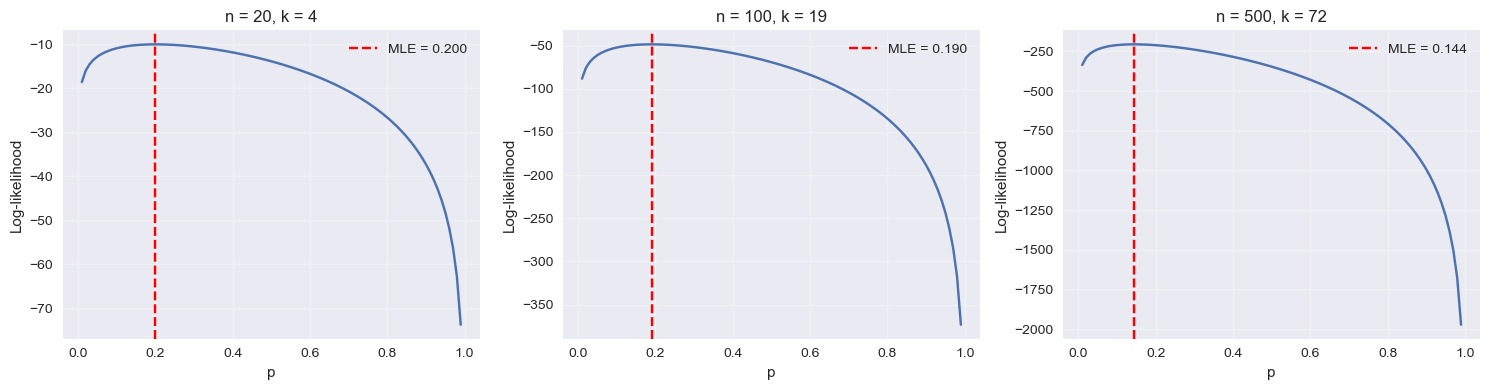

Key Insight: As sample size increases, the likelihood function becomes more peaked around the true parameter.
This illustrates the consistency property of MLE.


In [22]:
def bernoulli_log_likelihood(p, data):
    """Compute log-likelihood for Bernoulli model"""
    if p <= 0 or p >= 1:
        return -np.inf
    return np.sum(data * np.log(p) + (1 - data) * np.log(1 - p))

# Visualize likelihood for different sample sizes
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

p_grid = np.linspace(0.01, 0.99, 100)
sample_sizes = [20, 100, 500]

for i, n in enumerate(sample_sizes):
    # Generate data
    data = np.random.binomial(1, 0.15, n)
    k = np.sum(data)

    # Compute log-likelihood
    ll_values = [bernoulli_log_likelihood(p, data) for p in p_grid]

    # Plot
    axes[i].plot(p_grid, ll_values)
    axes[i].axvline(k/n, color='red', linestyle='--',
                   label=f'MLE = {k/n:.3f}')
    axes[i].set_xlabel('p')
    axes[i].set_ylabel('Log-likelihood')
    axes[i].set_title(f'n = {n}, k = {k}')
    axes[i].legend()
    axes[i].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("Key Insight: As sample size increases, the likelihood function becomes more peaked around the true parameter.")
print("This illustrates the consistency property of MLE.")

## 3. Real-World Application: Lifetime Data Analysis (Extension)

### 3.1 Dataset Description

We analyze lifetime data for industrial materials. The dataset contains failure times (in thousands of hours) for 20 materials. This type of data commonly arises in:
- Reliability engineering
- Survival analysis
- Quality control

**Research Question**: What is the typical lifetime of these materials?

=== Lifetime Data Analysis ===
Sample size: 20
Mean lifetime: 0.89 thousand hours
Median lifetime: 0.80 thousand hours
Min/Max: 0.1 / 1.6 thousand hours
Standard deviation: 0.41 thousand hours


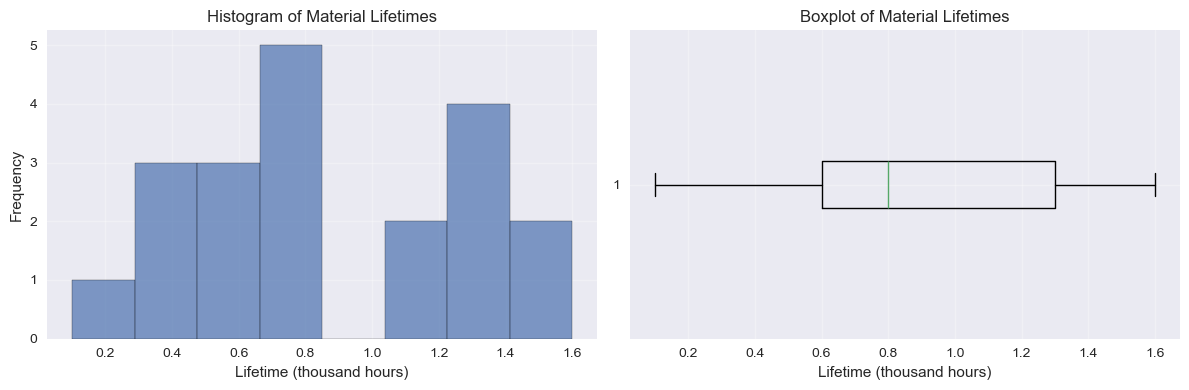

In [23]:
# Load the lifetime data
lifetimes_df = pd.read_csv('lifetimes.txt')
lifetimes = lifetimes_df['times'].values

print("=== Lifetime Data Analysis ===")
print(f"Sample size: {len(lifetimes)}")
print(f"Mean lifetime: {np.mean(lifetimes):.2f} thousand hours")
print(f"Median lifetime: {np.median(lifetimes):.2f} thousand hours")
print(f"Min/Max: {np.min(lifetimes):.1f} / {np.max(lifetimes):.1f} thousand hours")
print(f"Standard deviation: {np.std(lifetimes):.2f} thousand hours")

# Visualize the data
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.hist(lifetimes, bins=8, edgecolor='black', alpha=0.7)
plt.xlabel('Lifetime (thousand hours)')
plt.ylabel('Frequency')
plt.title('Histogram of Material Lifetimes')
plt.grid(True, alpha=0.3)

plt.subplot(1, 2, 2)
plt.boxplot(lifetimes, vert=False)
plt.xlabel('Lifetime (thousand hours)')
plt.title('Boxplot of Material Lifetimes')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### Question 3 — Explore the dataset

The Weibull distribution is commonly used for modeling lifetimes and failure times:

$$f(x|a) = a x^{a-1} \exp(-x^a), \quad x > 0, \; a > 0$$

**Why Weibull?**
- Flexible shape parameter a controls the failure rate
- a = 1: Constant failure rate (exponential)
- a > 1: Increasing failure rate (aging)
- a < 1: Decreasing failure rate (infant mortality)

**Applications**: Reliability engineering, survival analysis, material science.

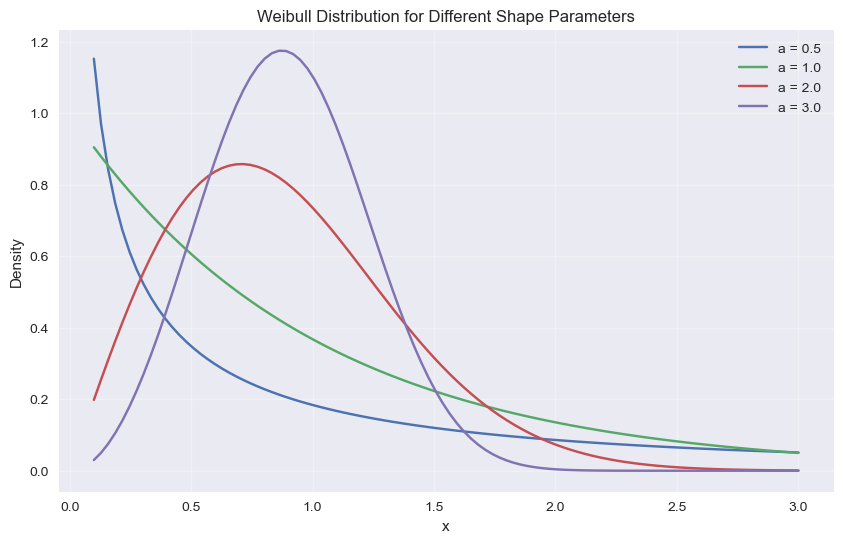

Interpretation:
- a = 0.5: Decreasing failure rate (infant mortality)
- a = 1.0: Constant failure rate (random failures)
- a = 2.0: Increasing failure rate (wear-out)
- a = 3.0: Strongly increasing failure rate (rapid aging)


In [24]:
def weibull_pdf(x, a):
    """Weibull probability density function"""
    if a <= 0:
        return np.zeros_like(x)
    return a * x**(a-1) * np.exp(-x**a)

def weibull_log_likelihood(a, x):
    """Log-likelihood for Weibull distribution"""
    if a <= 0:
        return -np.inf
    return np.sum(np.log(a) + (a-1)*np.log(x) - x**a)

def weibull_negative_log_likelihood(a, x):
    """Negative log-likelihood for minimization"""
    return -weibull_log_likelihood(a, x)

# Visualize Weibull densities for different shape parameters
x_plot = np.linspace(0.1, 3, 100)
a_values = [0.5, 1.0, 2.0, 3.0]

plt.figure(figsize=(10, 6))
for a in a_values:
    pdf_vals = weibull_pdf(x_plot, a)
    plt.plot(x_plot, pdf_vals, label=f'a = {a}')
plt.xlabel('x')
plt.ylabel('Density')
plt.title('Weibull Distribution for Different Shape Parameters')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

print("Interpretation:")
print("- a = 0.5: Decreasing failure rate (infant mortality)")
print("- a = 1.0: Constant failure rate (random failures)")
print("- a = 2.0: Increasing failure rate (wear-out)")
print("- a = 3.0: Strongly increasing failure rate (rapid aging)")

### Question 4 — Fit a Weibull model via MLE

Now let's estimate the Weibull shape parameter using MLE:

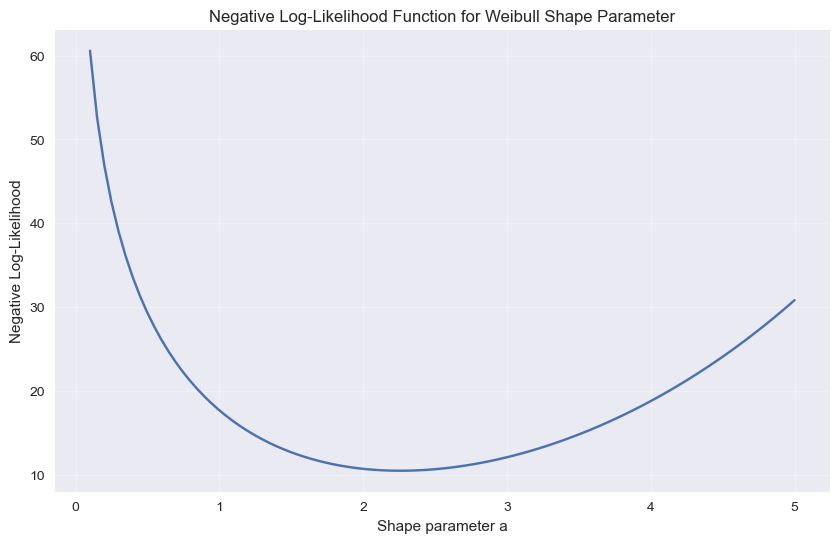

MLE for Weibull shape parameter: 2.2587
Optimization success: True
Function evaluations: 10


In [25]:
# Visualize the negative log-likelihood function
a_grid = np.linspace(0.1, 5, 100)
nll_values = [weibull_negative_log_likelihood(a, lifetimes) for a in a_grid]

plt.figure(figsize=(10, 6))
plt.plot(a_grid, nll_values)
plt.xlabel('Shape parameter a')
plt.ylabel('Negative Log-Likelihood')
plt.title('Negative Log-Likelihood Function for Weibull Shape Parameter')
plt.grid(True, alpha=0.3)
plt.show()

# Find MLE using numerical optimization
initial_guess = 2.0
result = optimize.minimize(weibull_negative_log_likelihood, initial_guess,
                          args=(lifetimes,), method='L-BFGS-B', bounds=[(0.01, None)])

a_hat_mle = result.x[0]
print(f"MLE for Weibull shape parameter: {a_hat_mle:.4f}")
print(f"Optimization success: {result.success}")
print(f"Function evaluations: {result.nfev}")

### Question 5 — Assess the fitted model

Let's assess how well the Weibull model fits our lifetime data:

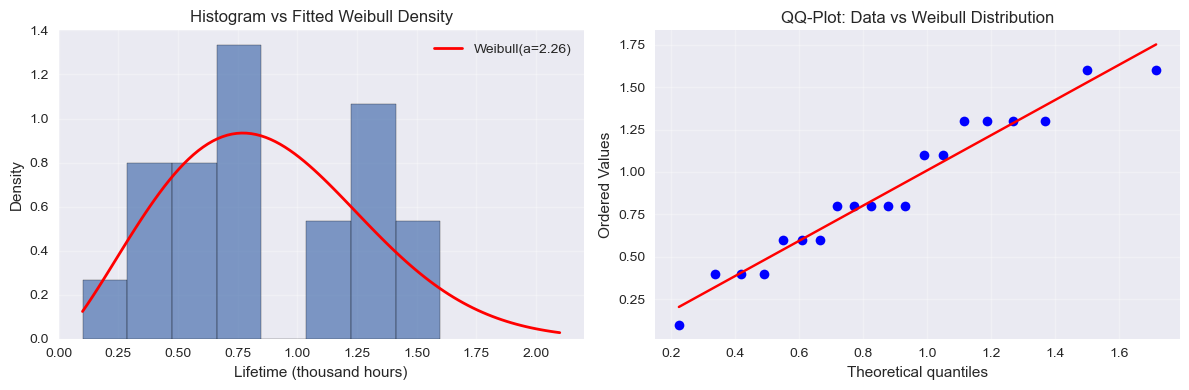

Fitted Weibull shape parameter: 2.2587
Interpretation: Increasing failure rate (materials wear out over time)


In [26]:
# Plot histogram vs fitted Weibull density
x_plot = np.linspace(0.1, np.max(lifetimes) + 0.5, 100)
fitted_pdf = weibull_pdf(x_plot, a_hat_mle)

plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.hist(lifetimes, bins=8, density=True, alpha=0.7, edgecolor='black')
plt.plot(x_plot, fitted_pdf, 'r-', linewidth=2, label=f'Weibull(a={a_hat_mle:.2f})')
plt.xlabel('Lifetime (thousand hours)')
plt.ylabel('Density')
plt.title('Histogram vs Fitted Weibull Density')
plt.legend()
plt.grid(True, alpha=0.3)

# QQ-plot for model assessment
plt.subplot(1, 2, 2)
# For QQ-plot, we need to compare quantiles
from scipy import stats as scistats
scistats.probplot(lifetimes, dist='weibull_min', sparams=(a_hat_mle,), plot=plt)
plt.title('QQ-Plot: Data vs Weibull Distribution')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"Fitted Weibull shape parameter: {a_hat_mle:.4f}")
if a_hat_mle > 1:
    print("Interpretation: Increasing failure rate (materials wear out over time)")
elif a_hat_mle < 1:
    print("Interpretation: Decreasing failure rate (infant mortality)")
else:
    print("Interpretation: Constant failure rate (random failures)")

## 4. Comparing MLE and Method of Moments (Extension)

### 4.1 Method of Moments (MoM) Estimator

The **Method of Moments** provides an alternative to MLE:

1. Compute theoretical moments m_k(θ) = E[X^k]
2. Compute sample moments m̂_k = (1/n) Σ x_i^k
3. Solve m_k(θ) = m̂_k for θ

For Weibull distribution, let's derive the MoM estimator.

In [27]:
def weibull_mom_estimator(data):
    """Method-of-moments estimate of the Weibull shape parameter.

    Uses the sample mean and variance to match the theoretical
    moment ratio Gamma(1 + 2/k) / Gamma(1 + 1/k)^2.
    Returns the estimated shape parameter k.
    """
    data = np.asarray(data, dtype=float)
    if data.size == 0 or np.any(data <= 0):
        raise ValueError("Weibull MoM estimator requires positive samples")

    sample_mean = data.mean()
    sample_var = data.var(ddof=1)
    if sample_mean <= 0:
        raise ValueError("Sample mean must be positive for Weibull MoM estimator")

    target = 1.0 + sample_var / sample_mean**2

    def objective(k):
        return gamma(1 + 2.0 / k) / gamma(1 + 1.0 / k)**2 - target

    # Build an adaptive bracket by scanning a grid in log space
    ks = np.logspace(-1, 1.2, 400)  # k in [0.1, ~15.8]
    vals = objective(ks)

    bracket = None
    for k_low, k_high, v_low, v_high in zip(ks[:-1], ks[1:], vals[:-1], vals[1:]):
        if np.isnan(v_low) or np.isnan(v_high):
            continue
        if v_low == 0:
            return float(k_low)
        if v_low * v_high < 0:
            bracket = (k_low, k_high)
            break

    if bracket is None:
        raise RuntimeError("Unable to bracket root for Weibull MoM estimator. "
                           "Check that the sample moments are compatible with a Weibull model.")

    result = optimize.root_scalar(objective, bracket=bracket)
    if not result.converged:
        raise RuntimeError("MoM solver did not converge")

    return float(result.root)


### Question 6 — Implement a method-of-moments estimator and compare it to MLE

Let's conduct a simulation study to compare the performance of MLE and MoM estimators across different sample sizes.

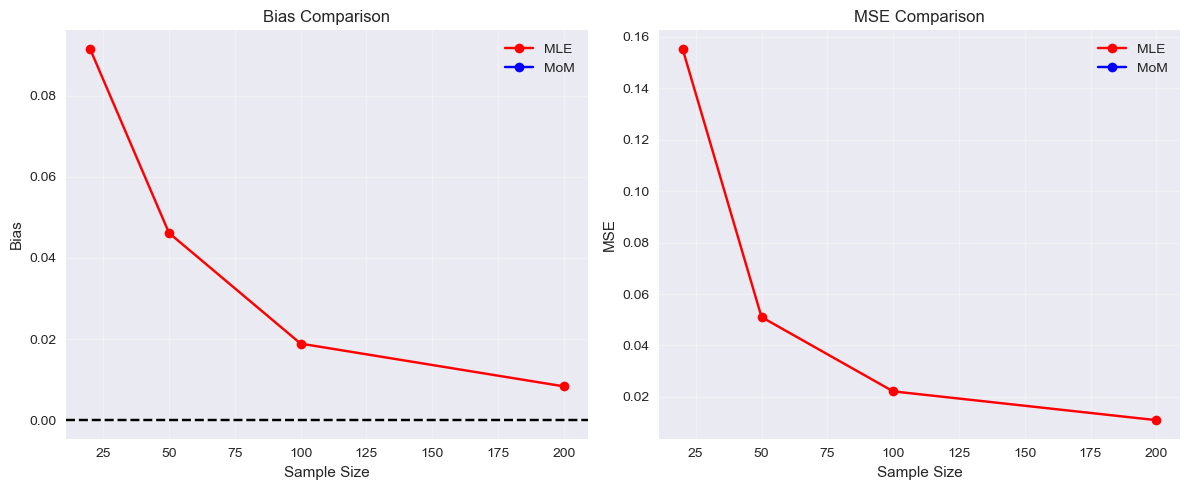

=== Simulation Study Results ===
True parameter: a = 2.0
n = 20:
  MLE - Bias: 0.0915, MSE: 0.1553
  MoM - Bias: nan, MSE: nan
n = 50:
  MLE - Bias: 0.0461, MSE: 0.0510
  MoM - Bias: nan, MSE: nan
n = 100:
  MLE - Bias: 0.0189, MSE: 0.0222
  MoM - Bias: nan, MSE: nan
n = 200:
  MLE - Bias: 0.0083, MSE: 0.0110
  MoM - Bias: nan, MSE: nan


In [28]:
def simulation_study(true_a, sample_sizes, n_simulations=1000):
    """Compare MLE and MoM performance via simulation"""
    results = {'n': [], 'mle_bias': [], 'mom_bias': [],
               'mle_mse': [], 'mom_mse': []}

    for n in sample_sizes:
        mle_estimates = []
        mom_estimates = []

        for _ in range(n_simulations):
            # Generate Weibull data
            data = stats.weibull_min.rvs(true_a, size=n)

            # MLE (numerical optimization)
            try:
                result = optimize.minimize(weibull_negative_log_likelihood, 2.0,
                                        args=(data,), method='L-BFGS-B', bounds=[(0.01, None)])
                mle_est = result.x[0] if result.success else np.nan
            except:
                mle_est = np.nan

            # MoM
            try:
                mom_est = weibull_mom_estimator(data)
            except:
                mom_est = np.nan

            if not np.isnan(mle_est):
                mle_estimates.append(mle_est)
            if not np.isnan(mom_est):
                mom_estimates.append(mom_est)

        # Compute performance metrics
        mle_estimates = np.array(mle_estimates)
        mom_estimates = np.array(mom_estimates)

        results['n'].append(n)
        results['mle_bias'].append(np.mean(mle_estimates) - true_a)
        results['mom_bias'].append(np.mean(mom_estimates) - true_a)
        results['mle_mse'].append(np.mean((mle_estimates - true_a)**2))
        results['mom_mse'].append(np.mean((mom_estimates - true_a)**2))

    return results

# Run simulation study
true_a = 2.0
sample_sizes = [20, 50, 100, 200]
sim_results = simulation_study(true_a, sample_sizes)

# Visualize results
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].plot(sim_results['n'], sim_results['mle_bias'], 'ro-', label='MLE')
axes[0].plot(sim_results['n'], sim_results['mom_bias'], 'bo-', label='MoM')
axes[0].axhline(0, color='black', linestyle='--')
axes[0].set_xlabel('Sample Size')
axes[0].set_ylabel('Bias')
axes[0].set_title('Bias Comparison')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(sim_results['n'], sim_results['mle_mse'], 'ro-', label='MLE')
axes[1].plot(sim_results['n'], sim_results['mom_mse'], 'bo-', label='MoM')
axes[1].set_xlabel('Sample Size')
axes[1].set_ylabel('MSE')
axes[1].set_title('MSE Comparison')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("=== Simulation Study Results ===")
print(f"True parameter: a = {true_a}")
for i, n in enumerate(sample_sizes):
    print(f"n = {n}:")
    print(f"  MLE - Bias: {sim_results['mle_bias'][i]:.4f}, MSE: {sim_results['mle_mse'][i]:.4f}")
    print(f"  MoM - Bias: {sim_results['mom_bias'][i]:.4f}, MSE: {sim_results['mom_mse'][i]:.4f}")

## 5. Uncertainty Quantification (Extension)

### 5.1 Fisher Information and Standard Errors

The **Fisher information** quantifies the amount of information about the parameter contained in the data:

$$I(a) = \mathbb{E}\left[ -\frac{\partial^2 \ell(a)}{\partial a^2} \right]$$

For large samples, the MLE is approximately normal:

$$\hat{a}_{\text{MLE}} \sim \mathcal{N}(a_{\text{true}}, I(a_{\text{true}})^{-1})$$

We can estimate the standard error using the **observed information**:

$$\widehat{\text{SE}}(\hat{a}) = \sqrt{I(\hat{a})^{-1}}$$

### Question 7 — Approximate the standard error via observed Fisher information

In [29]:
def fisher_information_weibull(a, data):
    """Compute observed Fisher information for Weibull shape parameter"""
    n = len(data)

    # Second derivative of log-likelihood
    # d²ℓ/da² = -n/a² - ∑[log(x_i)² * x_i^a * (a-1) - (log(x_i) * x_i^a)²]
    # This is complex for Weibull, so we'll use numerical differentiation

    def second_derivative(a_val):
        h = 1e-6
        f_plus = weibull_log_likelihood(a_val + h, data)
        f_minus = weibull_log_likelihood(a_val - h, data)
        f_center = weibull_log_likelihood(a_val, data)
        return (f_plus - 2*f_center + f_minus) / (h**2)

    return -second_derivative(a)

# Compute standard error for our MLE
fisher_info = fisher_information_weibull(a_hat_mle, lifetimes)
se_mle = 1 / np.sqrt(fisher_info)

print("=== Fisher Information and Standard Errors ===")
print(f"MLE: {a_hat_mle:.4f}")
print(f"Fisher information: {fisher_info:.4f}")
print(f"Standard error: {se_mle:.4f}")
print(f"95% Confidence interval: [{a_hat_mle - 1.96*se_mle:.4f}, {a_hat_mle + 1.96*se_mle:.4f}]")

=== Fisher Information and Standard Errors ===
MLE: 2.2587
Fisher information: 6.4624
Standard error: 0.3934
95% Confidence interval: [1.4877, 3.0297]


### Question 8 — Bootstrap confidence intervals

Bootstrap completed: 1000 successful replications
Bootstrap 95% CI: [1.6158, 3.1155]
Asymptotic 95% CI: [1.4877, 3.0297]


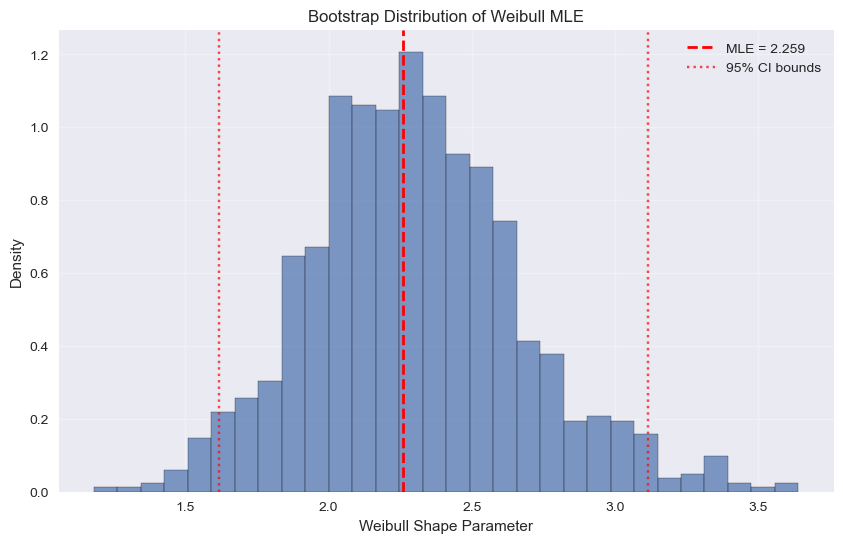

In [30]:
def bootstrap_weibull_mle(data, B=1000):
    """Bootstrap distribution of Weibull MLE"""
    n = len(data)
    bootstrap_estimates = []

    for _ in range(B):
        # Resample with replacement
        bootstrap_sample = np.random.choice(data, size=n, replace=True)

        # Fit MLE to bootstrap sample
        try:
            result = optimize.minimize(weibull_negative_log_likelihood, 2.0,
                                    args=(bootstrap_sample,), method='L-BFGS-B', bounds=[(0.01, None)])
            if result.success:
                bootstrap_estimates.append(result.x[0])
        except:
            pass

    return np.array(bootstrap_estimates)

# Compute bootstrap distribution
bootstrap_dist = bootstrap_weibull_mle(lifetimes, B=1000)

print(f"Bootstrap completed: {len(bootstrap_dist)} successful replications")

# Compute bootstrap confidence interval
alpha = 0.05
lower_percentile = np.percentile(bootstrap_dist, 100 * alpha/2)
upper_percentile = np.percentile(bootstrap_dist, 100 * (1 - alpha/2))

print(f"Bootstrap 95% CI: [{lower_percentile:.4f}, {upper_percentile:.4f}]")
print(f"Asymptotic 95% CI: [{a_hat_mle - 1.96*se_mle:.4f}, {a_hat_mle + 1.96*se_mle:.4f}]")

# Visualize bootstrap distribution
plt.figure(figsize=(10, 6))
plt.hist(bootstrap_dist, bins=30, density=True, alpha=0.7, edgecolor='black')
plt.axvline(a_hat_mle, color='red', linestyle='--', linewidth=2, label=f'MLE = {a_hat_mle:.3f}')
plt.axvline(lower_percentile, color='red', linestyle=':', alpha=0.7, label='95% CI bounds')
plt.axvline(upper_percentile, color='red', linestyle=':', alpha=0.7)
plt.xlabel('Weibull Shape Parameter')
plt.ylabel('Density')
plt.title('Bootstrap Distribution of Weibull MLE')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

## 6. Summary and Reflection

### 6.1 What We Learned

1. **Likelihood Principle**: MLE chooses parameters that make observed data most probable
2. **Derivation Process**: Take derivative of log-likelihood, set to zero, solve
3. **Comparison with MoM**: MLE generally more efficient but computationally intensive
4. **Uncertainty Quantification**: Fisher information and bootstrap provide standard errors
5. **Real-World Application**: Weibull distribution effectively models lifetime data

### 6.2 Connection to Previous Lessons

- **Lesson 1**: LLN justifies MLE consistency; CLT enables asymptotic inference
- **Lesson 2**: MLE is the primary tool for parameter estimation in statistical learning
- **Practical Link**: Theory enables real applications like reliability engineering

### 6.3 Best Practices

1. **Always check optimization convergence** when using numerical methods
2. **Use multiple starting points** for non-convex likelihood surfaces
3. **Compare with alternative estimators** (MoM, robust methods)
4. **Assess model fit** using QQ-plots and other diagnostic tools
5. **Report uncertainty** using confidence intervals or standard errors
6. **Validate with simulations** when theoretical results are unclear

In [31]:
# Final summary statistics
print("=== Final Summary ===")
print(f"Dataset: {len(lifetimes)} material lifetimes")
print(f"Sample mean: {np.mean(lifetimes):.3f} thousand hours")
print(f"Sample median: {np.median(lifetimes):.3f} thousand hours")
print(f"\nWeibull MLE shape parameter: {a_hat_mle:.4f}")
print(f"Standard error: {se_mle:.4f}")
print(f"95% Confidence interval: [{a_hat_mle - 1.96*se_mle:.4f}, {a_hat_mle + 1.96*se_mle:.4f}]")
print(f"\nInterpretation: The data suggests {'increasing' if a_hat_mle > 1 else 'decreasing' if a_hat_mle < 1 else 'constant'} failure rate.")
print("\nThis analysis demonstrates how MLE enables quantitative reliability assessment.")

=== Final Summary ===
Dataset: 20 material lifetimes
Sample mean: 0.885 thousand hours
Sample median: 0.800 thousand hours

Weibull MLE shape parameter: 2.2587
Standard error: 0.3934
95% Confidence interval: [1.4877, 3.0297]

Interpretation: The data suggests increasing failure rate.

This analysis demonstrates how MLE enables quantitative reliability assessment.


### Question 9 — Summarise your findings